In [ ]:
# old final preprocessing
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps (From your code) ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

STANDARD_STOPWORDS = set(stopwords.words('english'))
stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Masking ---
def preprocess_masked(text):
    # First, run the full strategy
    text = preprocess_full(text)

    # Then apply the specific semantic masks before returning
    text = re.sub(r'\b[a-z]{3}\d+\.?\d*[a-z]{1,2}\b', ' [MONEY_METRIC] ', text)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # Clean up extra spaces
    return re.sub(r'\s+', ' ', text).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Basic punctuation removal
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    # Standard NLTK stopwords (loses words like "up", "down", "no")
    filtered = [word for word in tokens if word not in STANDARD_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/fabianhensel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [1]:
# current final preprocessing

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords')
nltk.download('punkt')

# --- Configurations & Maps ---
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    # Punctuation/Noise
    '-', "''", "'",
    # Numbers & Timeline metadata
    '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end',
    # Entities & Locations
    'finnish', 'finland', 'helsinki', 'hel', 'nokia',
    # Corporate Boilerplate
    'oyj', 'oy', 'corpor', 'omx', 'group', 'compani',
    # Generic Verbs & English Stop Words
    'said', 'also', 'includ', 'accord', 'use', 'well',
    'per', 'part', 'would', 'base', 'provid'
}

PRESERVED_WORDS = {
    'good', 'bad', 'high', 'low', 'risk', 'profit', 'loss',
    'up', 'down', 'increase', 'decrease', 'increas', 'decreas',
    'strong', 'weak', 'better', 'worse', 'positive', 'negative',
    'stable', 'volatile', 'only', 'below', 'few', 'more',
    'no', 'not', 'nor', 'over', 'should', 'but'
}

english_defaults = set(stopwords.words('english'))

CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

stemmer = PorterStemmer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"),
    (re.compile(r"\$"), "usd"),
    (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"),
    (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "),
    (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)

    return text

# --- Isolated Core Cleaning Pipeline ---
def _normalize_text_pipeline(text):
    """Executes all structural cleanups, standardizations, and maps."""
    if not isinstance(text, str):
        return ""
    text = text.lower()

    # Extract phone numbers early
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)

    # Cleanups and Normalizations
    for reg, repl in EARLY_CLEANUP:
        text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items():
        text = word_regex.sub(num, text)

    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)

    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP):
        text = reg.sub(repl, text)

    # Re-insert compressed phone formats
    for p in phones:
        text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)

    return text

# --- Strategy 1: Full Preprocessing ---
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = [word for word in text.split() if word not in CUSTOM_STOPWORDS]
    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_tokens).strip()

# --- Strategy 2: Full Preprocessing + Comprehensive Masking ---
def preprocess_masked(text):
    text = _normalize_text_pipeline(text)

    # 1. Mask Phone Numbers (e.g. +123456789)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE_MARKER] ', text)

    # 2. Mask Money / Currency metrics (e.g., usd100mn, eur5.5k, usd20)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY_METRIC] ', text)

    # 3. Mask Standalone Percentages (e.g., 10pct, 5.5pct)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)

    # 4. Mask Standardized Date Formats (Full ISO, Year-Month, Month-Month, Years)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)

    # 5. Mask Standardized Time Formats (e.g., 12:00am, 4:30pm)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME_MARKER] ', text)

    # 6. Mask Measurements and Physical Units (e.g., 50sqm, 10m, 5km, 20kg, 100g)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT_MARKER] ', text)

    # 7. Mask Generic Leftover Numbers (e.g., standalone quantities, counts)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER_MARKER] ', text)

    # Tokenize and Stem standard vocabulary while shielding our new placeholders
    tokens = text.split()
    processed_tokens = []

    mask_placeholders = {
        '[PHONE_MARKER]', '[MONEY_METRIC]', '[PERCENT_METRIC]',
        '[DATE_MARKER]', '[TIME_MARKER]', '[MEASUREMENT_MARKER]', '[NUMBER_MARKER]'
    }

    for word in tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        elif word not in CUSTOM_STOPWORDS:
            processed_tokens.append(stemmer.stem(word))

    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

# --- Strategy 3: Standard / Simple Preprocessing ---
def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    filtered = [word for word in tokens if word not in CUSTOM_STOPWORDS]
    stemmed = [stemmer.stem(word) for word in filtered]
    return " ".join(stemmed).strip()


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import itertools  # Necessary for Phase 2 Custom Grid Search

# Set seed for reproducibility
torch.manual_seed(42)

# --- Define PyTorch Feed-Forward Neural Network Class ---
class FinancialFFNN(nn.Module):
    def __init__(self, input_dim, hidden_layers=(64,), num_classes=3, activation='relu'):
        super(FinancialFFNN, self).__init__()

        # Select activation function
        if activation == 'relu':
            self.activation = nn.ReLU()
        elif activation == 'tanh':
            self.activation = nn.Tanh()
        else:
            self.activation = nn.ReLU()

        # Build dynamic linear layers
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(self.activation)
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# --- Helper Function to Train PyTorch Model ---
def train_pytorch_model(X_train_sparse, y_train, hidden_layers=(64,), activation='relu', lr=0.001, epochs=20, batch_size=32):
    # Convert sparse matrices directly to dense PyTorch tensors
    X_tensor = torch.tensor(X_train_sparse.toarray(), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(y_train), dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    num_classes = len(np.unique(y_tensor.numpy()))
    model = FinancialFFNN(input_dim=X_tensor.shape[1], hidden_layers=hidden_layers, num_classes=num_classes, activation=activation)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    return model

# --- Helper Function to Predict using PyTorch Model ---
def predict_pytorch_model(model, X_test_sparse):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_test_sparse.toarray(), dtype=torch.float32)
        outputs = model(X_tensor)
        _, predicted = torch.max(outputs, 1)
    return predicted.numpy()


Starting the Grand Evaluation Loop. This may take a few minutes...

---> Processing Strategy: PREP_STANDARD
     N-Gram: (1, 1)

---> Processing Strategy: PREP_FULL
     N-Gram: (1, 1)

---> Processing Strategy: PREP_MASKED
     N-Gram: (1, 1)

Evaluation Complete!

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6243     0.6393       0.6616
                TF-IDF     (1, 1)         0.6526     0.6540       0.6591
Naive Bayes     BoW        (1, 1)         0.6079     0.6421       0.6093
                TF-IDF     (1, 1)         0.5956     0.6306       0.6195


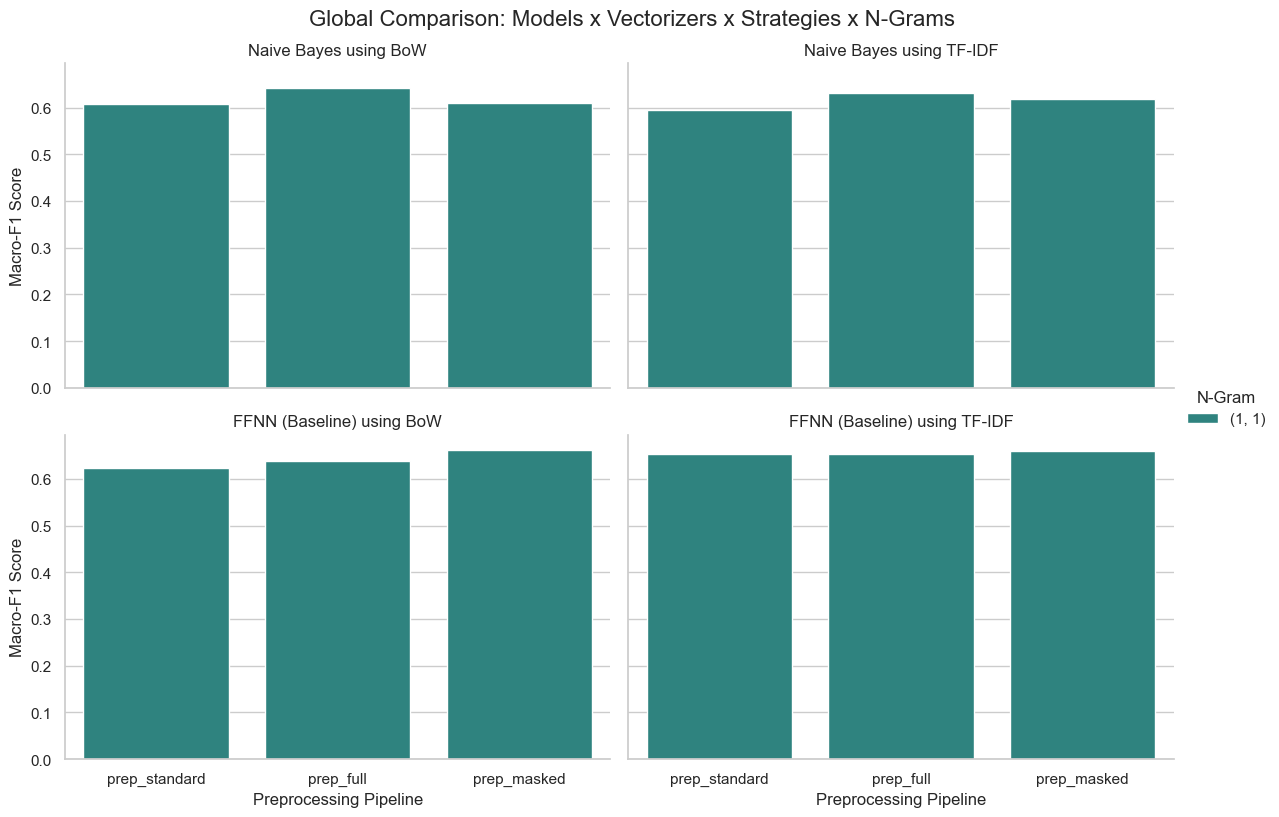


========================= FEATURE SIZE MATRIX =========================
Strategy           prep_full  prep_masked  prep_standard
Vectorizer N-Gram                                       
BoW        (1, 1)     8859.0       6697.0         6870.0
TF-IDF     (1, 1)     8859.0       6697.0         6870.0


In [ ]:
# not gpu
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred, model_display_name, classes):
    print(f"\n================ {model_display_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix (FIX: Removed labels=classes to prevent integer/string mismatch)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'CM: {model_display_name}', fontsize=10)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# --- Data Loading and Encoding ---
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])
classes_multiclass = label_encoder.classes_  # Keeps string names for display

# Prepare columns (Assuming these preprocessing functions are defined in your environment)
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

# Setup Iterations
ngram_ranges = [
    (1, 1), (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 2), (2, 3), (2, 4), (2, 5),
    (3, 3), (3, 4), (3, 5),
    (4, 4), (4, 5),
    (5, 5)
]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []

models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": MLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

print("Starting the Grand Evaluation Loop. This may take a few minutes...")
feature_sizes = []

for strategy in strategies:
    print(f"\n---> Processing Strategy: {strategy.upper()}")

    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    smote_tomek = SMOTETomek(random_state=42)

    for ngram in ngram_ranges:
        print(f"     N-Gram: {ngram}")

        # --- 1. BoW Pipeline ---
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "BoW",
            "N-Gram": str(ngram),
            "Feature_Size": len(count_vect.get_feature_names_out())
        })

        # --- 2. TF-IDF Pipeline ---
        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "TF-IDF",
            "N-Gram": str(ngram),
            "Feature_Size": len(tfidf_vect.get_feature_names_out())
        })

        # --- 3. Test & Evaluate Models ---
        for model_name, model_instance in models.items():

            # --- BoW Evaluation ---
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "BoW",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow),
                "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            # Call your custom evaluation function for BoW
            bow_title = f"{model_name} (BoW | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_bow, bow_title, classes_multiclass)

            # --- TF-IDF Evaluation ---
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "TF-IDF",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf),
                "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

            # Call your custom evaluation function for TF-IDF
            tfidf_title = f"{model_name} (TF-IDF | {strategy} | {ngram})"
            # evaluate_model(y_test, y_pred_tfidf, tfidf_title, classes_multiclass)

results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- Global Aggregations ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")

sns.set_theme(style="whitegrid")
g = sns.catplot(
    data=results_df,
    x='Strategy',
    y='Macro-F1',
    hue='N-Gram',
    col='Vectorizer',
    row='Model',
    kind='bar',
    palette="viridis",
    height=4,
    aspect=1.5
)
g.fig.suptitle("Global Comparison: Models x Vectorizers x Strategies x N-Grams", y=1.02, fontsize=16)
g.set_titles("{row_name} using {col_name}")
g.set_axis_labels("Preprocessing Pipeline", "Macro-F1 Score")
plt.show()

feature_sizes_df = pd.DataFrame(feature_sizes)
feature_pivot = pd.pivot_table(
    feature_sizes_df,
    values="Feature_Size",
    index=["Vectorizer", "N-Gram"],
    columns=["Strategy"]
)

print("\n========================= FEATURE SIZE MATRIX =========================")
print(feature_pivot)
print("=====================================================================")


In [ ]:
import pprint
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pprint.pprint(df["prep_masked"])

from collections import Counter
import pprint

# Alle Wörter aus der Spalte "prep_full" in eine Liste umwandeln
all_words = []
for text in df["prep_full"]:
    if isinstance(text, str):  # Überprüfen, ob der Eintrag ein String ist
        words = text.split()  # Text in Wörter aufteilen
        all_words.extend(words)  # Wörter zur Liste hinzufügen

# Häufigkeit der Wörter zählen
word_counts = Counter(all_words)

# Die 50 häufigsten Wörter extrahieren
most_common_words = word_counts.most_common(100)

# Ergebnis anzeigen
pprint.pprint(most_common_words)


0                                                                                                                                                                                                                                                                                                      accord gran compani no plan move product russia although compani grow
1                                                                                                                                                                                                                                       technopoli plan develop stage area no less [NUMBER_MARKER] squar meter order host compani work comput technolog telecommun statement
2                                                                                                                                                                                                                    intern electron industri compani elcoteq laid ten employe

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

def evaluate_model(y_true, y_pred, model_name, classes):
    print(f"\n================ {model_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()


In [ ]:
# simple bow and tfidf test
classes_multiclass = sorted(list(y_train.unique()))

feature_size = None
count_vect = CountVectorizer(max_features=feature_size, ngram_range=(2,3))

X_train_bow = count_vect.fit_transform(X_train_raw)
X_test_bow = count_vect.transform(X_test_raw)

nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train)
y_pred_nb_bow = nb_bow.predict(X_test_bow)

evaluate_model(y_test, y_pred_nb_bow, "Naive Bayes (boW)", classes_multiclass)

tfidf_vect = TfidfVectorizer(max_features=feature_size, token_pattern=r'(?u)\[?\b\w[-\w\.]*\b\]?')
X_train_tfidf = tfidf_vect.fit_transform(X_train_raw)
X_test_tfidf = tfidf_vect.transform(X_test_raw)

nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)
y_pred_nb_tfidf = nb_tfidf.predict(X_test_tfidf)
evaluate_model(y_test, y_pred_nb_tfidf, "Naive Bayes (TF-IDF)", classes_multiclass)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 9.4 MB/s  0:00:00 eta 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# --- Stub Preprocessing Functions ---
def preprocess_standard(text): return text
def preprocess_full(text): return text
def preprocess_masked(text): return text

# --- Evaluation Function ---
def evaluate_model(y_true, y_pred, model_display_name, classes):
    print(f"\n================ {model_display_name} Evaluation ================")
    print(classification_report(y_true, y_pred, target_names=classes))

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f} | Macro F1-Score: {macro_f1:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(f'CM: {model_display_name}', fontsize=10)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


# --- GPU-Accelerated PyTorch Wrapper (Updated for Mac M1/M2/M3) ---
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=50, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.model = None
        self.classes_ = None

        # MAC ACCELERATION: Target Apple Silicon MPS before defaulting to CPU
        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"):
            X = X.toarray()

        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu':
                layers.append(nn.ReLU())
            elif self.activation == 'tanh':
                layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model = nn.Sequential(*layers).to(self.device)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 5

        for epoch in range(self.max_iter):
            self.model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        outputs = self.model(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience:
                        break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"):
            X = X.toarray()

        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)

        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)

        return predicted.cpu().numpy()


# --- Data Loading and Encoding ---
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])
classes_multiclass = label_encoder.classes_

df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

ngram_ranges = [
    (1, 1), (1, 2), (1, 3),
    (2, 2), (2, 3),
    (3, 3),
]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []

models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64,),
        activation='relu',
        solver='adam',
        max_iter=50,
        early_stopping=True,
        random_state=42
    )
}

# Print exact hardware optimization announcement
if torch.backends.mps.is_available():
    active_device = "Apple Silicon GPU Acceleration (MPS)"
elif torch.cuda.is_available():
    active_device = "GPU Acceleration (CUDA)"
else:
    active_device = "CPU Execution Loop"

print(f"Starting the Grand Evaluation Loop on: {active_device}.")
print("Multiprocessing active on CPU for Vectorization and Resampling tasks.\n")
feature_sizes = []

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")

    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    # CPU ACCELERATION: Tell SMOTE to spin up all available processor cores
    smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

    for ngram in ngram_ranges:
        print(f"     N-Gram: {ngram}")

        # --- 1. BoW Pipeline ---
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "BoW",
            "N-Gram": str(ngram),
            "Feature_Size": len(count_vect.get_feature_names_out())
        })

        # --- 2. TF-IDF Pipeline ---
        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        feature_sizes.append({
            "Strategy": strategy,
            "Vectorizer": "TF-IDF",
            "N-Gram": str(ngram),
            "Feature_Size": len(tfidf_vect.get_feature_names_out())
        })

        # --- 3. Test & Evaluate Models ---
        for model_name, original_model_instance in models.items():

            model_instance = clone(original_model_instance)

            # --- BoW Evaluation ---
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "BoW",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow),
                "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            model_instance = clone(original_model_instance)

            # --- TF-IDF Evaluation ---
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name,
                "Strategy": strategy,
                "Vectorizer": "TF-IDF",
                "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf),
                "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- Global Aggregations ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")


Starting the Grand Evaluation Loop on: Apple Silicon GPU Acceleration (MPS).
Multiprocessing active on CPU for Vectorization and Resampling tasks.

---> Processing Strategy: PREP_STANDARD
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)
---> Processing Strategy: PREP_FULL
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)
---> Processing Strategy: PREP_MASKED
     N-Gram: (1, 1)
     N-Gram: (1, 2)
     N-Gram: (1, 3)
     N-Gram: (2, 2)
     N-Gram: (2, 3)
     N-Gram: (3, 3)

Evaluation Complete!

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6469     0.6469       0.6469
                           (1, 2)         0

In [ ]:
results_df = pd.DataFrame(results)
print("\nEvaluation Complete!")

# --- 1. Save the Raw Data for Later Plotting (Crucial) ---
# This keeps every single row, model, and metric intact
results_df.to_csv("raw_evaluation_results.csv", index=False)
print("Saved raw results to 'raw_evaluation_results.csv'")

# --- 2. Save your Summary Matrix ---
big_matrix = pd.pivot_table(
    results_df,
    values='Macro-F1',
    index=['Model', 'Vectorizer', 'N-Gram'],
    columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

# Save the pivot table (index=True because Model/Vectorizer/N-Gram are the index)
big_matrix.to_csv("macro_f1_pivot_matrix.csv", index=True)
print("Saved pivot matrix to 'macro_f1_pivot_matrix.csv'")



Evaluation Complete!
Saved raw results to 'raw_evaluation_results.csv'
Saved pivot matrix to 'macro_f1_pivot_matrix.csv'


In [ ]:
print("\n========== PHASE 2: GRID SEARCH ON THE WINNING COMBINATION ==========")

# 1. Re-isolate the winning data configuration
BEST_STRATEGY = "prep_masked"
BEST_NGRAM = (1, 2)

df_winner = df.dropna(subset=[BEST_STRATEGY, TARGET_COL]).reset_index(drop=True)
X_train_win, X_test_win, y_train_win, y_test_win = train_test_split(
    df_winner[BEST_STRATEGY], df_winner[TARGET_COL],
    test_size=0.20, random_state=42, stratify=df_winner[TARGET_COL]
)

final_vect = TfidfVectorizer(ngram_range=BEST_NGRAM, token_pattern=custom_token_pattern)
X_train_final = final_vect.fit_transform(X_train_win)
X_test_final = final_vect.transform(X_test_win)

# 2. PyTorch Compatible Grid Search Parameter Configuration Matrix
param_grid = {
    'hidden_layer_sizes': [(32,), (64,), (32, 32), (64, 32)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'alpha': [0.0001, 0.001, 0.01],
    'batch_size': [16, 32],
    'learning_rate_init': [0.001, 0.01, 0.1],
    'max_iter': [20, 50, 100],
    'early_stopping': [True],
    'validation_fraction': [0.1],
    'random_state': [42]
}

# Initializing PyTorch model abstraction instead of MLPClassifier
pytorch_mlp = PyTorchMLPClassifier()
grid_search = GridSearchCV(
    estimator=pytorch_mlp,
    param_grid=param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=1,
    verbose=2
)

print(f"Executing Grid Search on {X_train_final.shape[0]} samples and {X_train_final.shape[1]} features...")
grid_search.fit(X_train_final, y_train_win)

print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation F1-score: {grid_search.best_score_:.4f}")

# 3. Final Evaluation using PyTorch Architecture output
best_model = grid_search.best_estimator_
y_pred_mlp = best_model.predict(X_test_final)

evaluate_model(y_test_win, y_pred_mlp, f"Tuned PyTorch FFNN ({BEST_STRATEGY}, TF-IDF, {BEST_NGRAM})", classes_multiclass)



========== PHASE 2: GRID SEARCH ON THE WINNING COMBINATION ==========
Executing Grid Search on 3876 samples and 52313 features...
Fitting 3 folds for each of 864 candidates, totalling 2592 fits


KeyboardInterrupt: 

In [ ]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# --- ERWEITERTER DOWNLOAD-BLOCK (Fix für den LookupError) ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)                       # Neu für modernisierte Tokenizer
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)   # Neu für NLTK POS-Tagging

# ==========================================
# 1. PREPROCESSING CONFIGURATIONS & MAPS
# ==========================================
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    '-', "''", "'", '2009', '2008', '2007', '2006', '2010', '2005', '1', '2',
    'year', 'period', 'quarter', 'today', 'first', 'end', 'finnish', 'finland',
    'helsinki', 'hel', 'nokia', 'corporate', 'corporation', 'oyj', 'oy', 'omx', 'group', 'company',
    'said', 'also', 'include', 'including', 'accord', 'according', 'use', 'per', 'part', 'would',
    'base', 'provide'
}

PRESERVED_WORDS = {
    'below', 'but', 'down', 'few', 'more', 'no', 'nor',
    'not', 'only', 'over', 'should', 'up'
}

english_defaults = set(stopwords.words('english'))
CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

lemmatizer = WordNetLemmatizer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)-([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"), (re.compile(r"\$"), "usd"), (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"), (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "), (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}-{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}-{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)
    return text

def _normalize_text_pipeline(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)
    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)
    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)
    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

# ==========================================
# 2. LEMMATIZATION PREPROCESSING STRATEGIES
# ==========================================
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    lemmatized_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            lemmatized_tokens.append(lemma)
    return " ".join(lemmatized_tokens).strip()

def preprocess_masked(text):
    text = _normalize_text_pipeline(text)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE_MARKER] ', text)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY_METRIC] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT_METRIC] ', text)
    text = re.sub(r'\b\d{4}-\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{4}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{2}-\d{2}\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE_MARKER] ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT_MARKER] ', text)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER_MARKER] ', text)

    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    mask_placeholders = {
        '[PHONE_MARKER]', '[MONEY_METRIC]', '[PERCENT_METRIC]',
        '[DATE_MARKER]', '[TIME_MARKER]', '[MEASUREMENT_MARKER]', '[NUMBER_MARKER]'
    }
    processed_tokens = []
    for word, tag in tagged_tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        else:
            word_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=word_pos)
            if lemma not in CUSTOM_STOPWORDS:
                processed_tokens.append(lemma)
    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()

# ==========================================
# 3. PYTORCH MODEL WRAPPER
# ==========================================
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=50, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.model = None
        self.classes_ = None

        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu': layers.append(nn.ReLU())
            elif self.activation == 'tanh': layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model = nn.Sequential(*layers).to(self.device)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 5

        for epoch in range(self.max_iter):
            self.model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        outputs = self.model(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience: break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

# ==========================================
# 4. MAIN GRAND EVALUATION LOOP
# ==========================================
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])

print("Applying real preprocessing routines to the text dataset...")
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []
models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Baseline)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64,), activation='relu', solver='adam',
        max_iter=50, early_stopping=True, random_state=42
    )
}

if torch.backends.mps.is_available(): active_device = "Apple Silicon GPU Acceleration (MPS)"
elif torch.cuda.is_available(): active_device = "GPU Acceleration (CUDA)"
else: active_device = "CPU Execution Loop"

print(f"Starting evaluation on: {active_device}.\n")

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    from imblearn.combine import SMOTETomek
    smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

    for ngram in ngram_ranges:
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        for model_name, original_model_instance in models.items():
            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "BoW", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow), "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "TF-IDF", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf), "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

results_df = pd.DataFrame(results)
big_matrix = pd.pivot_table(
    results_df, values='Macro-F1', index=['Model', 'Vectorizer', 'N-Gram'], columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")


Applying real preprocessing routines to the text dataset...
Starting evaluation on: Apple Silicon GPU Acceleration (MPS).

---> Processing Strategy: PREP_STANDARD
---> Processing Strategy: PREP_FULL
---> Processing Strategy: PREP_MASKED

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                           prep_standard  prep_full  prep_masked
Model           Vectorizer N-Gram                                       
FFNN (Baseline) BoW        (1, 1)         0.6301     0.6313       0.6289
                           (1, 2)         0.5850     0.6182       0.6227
                           (1, 3)         0.5707     0.6057       0.6169
                           (2, 2)         0.4093     0.4020       0.4526
                           (2, 3)         0.3717     0.3691       0.4304
                           (3, 3)         0.2702     0.2372       0.3099
                TF-IDF     (1, 1)         0.6731     0.7066       0.7002
            


Generating publication-quality performance grid...
Graphic saved successfully as 'sentiment_evaluation_matrix.png'!


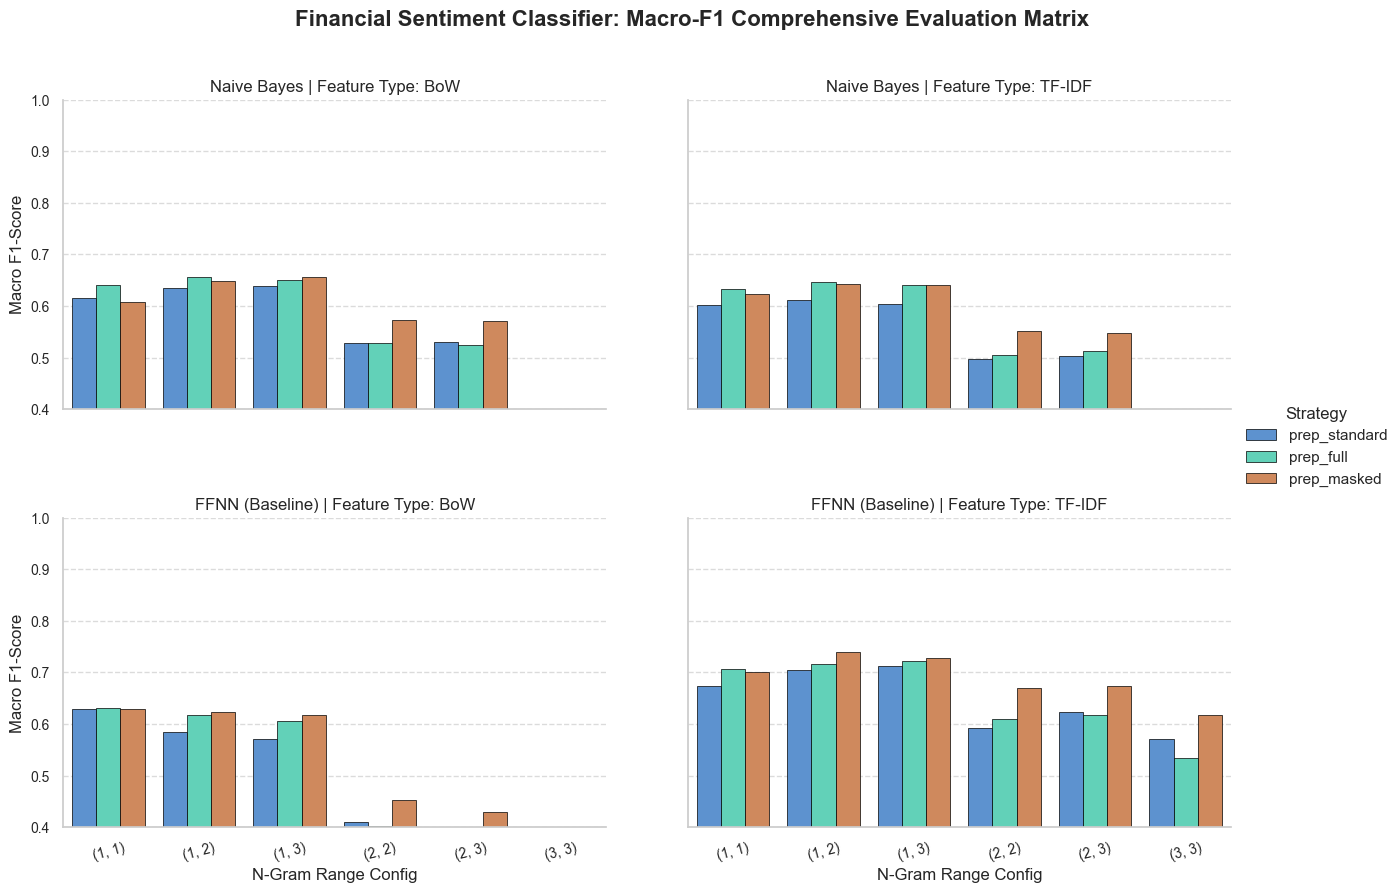

In [9]:
# ==========================================
# 5. SCIENTIFIC VISUALIZATION BLOCK
# ==========================================

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Define a clean, academic, colorblind-friendly palette
strategy_colors = {
    'prep_standard': '#4A90E2',  # Soft Blue
    'prep_full': '#50E3C2',      # Mint Green
    'prep_masked': '#E2844A'     # Muted Orange
}

print("\nGenerating publication-quality performance grid...")

# Initialize the structural grid: Rows = Models, Columns = Vectorizers
g = sns.catplot(
    data=results_df,
    x="N-Gram",
    y="Macro-F1",
    hue="Strategy",
    row="Model",
    col="Vectorizer",
    kind="bar",
    palette=strategy_colors,
    edgecolor="black",
    linewidth=0.5,
    height=4.5,
    aspect=1.4,
    sharex=True,
    sharey=True
)

# Refine layouts, axis titles, and limit parameters cleanly
g.set_axis_labels("N-Gram Range Config", "Macro F1-Score")
g.set_titles(row_template="{row_name}", col_template="Feature Type: {col_name}")

# Fine-tune visual details for each subplot
for ax in g.axes.flat:
    # Set realistic boundaries to highlight differences (adjust min bound based on your data)
    ax.set_ylim(0.40, 1.00)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.xaxis.grid(False) # Drop vertical grids to increase scannability

    # Rotate text labels slightly to prevent overlapping text elements
    for label in ax.get_xticklabels():
        label.set_rotation(15)

# Adjust margins and fix the position of the legend safely
g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.15)
g.fig.suptitle("Financial Sentiment Classifier: Macro-F1 Comprehensive Evaluation Matrix", weight="bold")

# Save a crisp, high-resolution vector image for your report text editor
plt.savefig("sentiment_evaluation_matrix.png", dpi=300, bbox_inches='tight')
print("Graphic saved successfully as 'sentiment_evaluation_matrix.png'!")
plt.show()


In [49]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.base import clone

# PyTorch Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# --- ERWEITERTER DOWNLOAD-BLOCK (Fix für den LookupError) ---
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)                       # Neu für modernisierte Tokenizer
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)   # Neu für NLTK POS-Tagging

# ==========================================
# 1. PREPROCESSING CONFIGURATIONS & MAPS
# ==========================================
MONTH_MAP = {
    'jan': '01', 'january': '01', 'feb': '02', 'february': '02',
    'mar': '03', 'march': '03', 'apr': '04', 'april': '04',
    'may': '05', 'jun': '06', 'june': '06',
    'jul': '07', 'july': '07', 'aug': '08', 'august': '08',
    'sep': '09', 'september': '09', 'oct': '10', 'october': '10',
    'nov': '11', 'november': '11', 'dec': '12', 'december': '12'
}

WRITTEN_NUMS = {
    re.compile(r'\bone\b', re.I): '1', re.compile(r'\btwo\b', re.I): '2',
    re.compile(r'\bthree\b', re.I): '3', re.compile(r'\bfour\b', re.I): '4',
    re.compile(r'\bfive\b', re.I): '5', re.compile(r'\bsix\b', re.I): '6',
    re.compile(r'\bseven\b', re.I): '7', re.compile(r'\beight\b', re.I): '8',
    re.compile(r'\bnine\b', re.I): '9', re.compile(r'\bten\b', re.I): '10'
}

FINANCIAL_NOISE_STOPWORDS = {
    '-', "''", "'",
    'year', 'period', 'quarter', 'today', 'first', 'end', 'finnish', 'finland',
    'helsinki', 'hel', 'nokia', 'corporate', 'corporation', 'oyj', 'oy', 'omx', 'group', 'company',
    'said', 'also', 'include', 'including', 'accord', 'according', 'use', 'per', 'part', 'would',
    'base', 'provide'
}

PRESERVED_WORDS = {
    'below', 'but', 'down', 'few', 'more', 'no', 'nor',
    'not', 'only', 'over', 'should', 'up'
}

english_defaults = set(stopwords.words('english'))
CUSTOM_STOPWORDS = (english_defaults | FINANCIAL_NOISE_STOPWORDS) - PRESERVED_WORDS

lemmatizer = WordNetLemmatizer()

PHONE_NUMBER = re.compile(r"(?<!\w)\+[\d\s\-\(\)]{6,20}(?!\w)")
STOCK_TICKER = re.compile(r"\([A-Z]+(\s*:\s*[A-Z0-9]+)?\)")
PHONE_PLACEHOLDER = "__PHONE__"

DATE_RANGE_WITH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})\s*-\s*([a-zA-Z]+)\s+(\d{1,2})\s*,?\s*(\d{4})\b", re.I)
MONTH_MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_MONTH = re.compile(r"\b([a-zA-Z]+)[-\s]+([a-zA-Z]+)\b", re.I)
DAY_MONTH_YEAR = re.compile(r"\b(\d{1,2})\s+([a-zA-Z]+)\s+(\d{4})\b", re.I)
MONTH_DAY_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{1,2})[,\s]+(\d{4})\b", re.I)
MONTH_YEAR = re.compile(r"\b([a-zA-Z]+)\s+(\d{4})\b", re.I)
YEAR_MONTH = re.compile(r"\b(\d{4})\s+([a-zA-Z]+)\b", re.I)

EARLY_CLEANUP = [
    (re.compile(r"(x[0-9a-fA-F]{4}|[^\x00-\x7F]+)"), " "),
    (re.compile(r"(\d+)(st|nd|rd|th)", re.I), r"\1"),
    (re.compile(r"(\d)\s(\d)"), r"\1\2"),
    (re.compile(r"(\.)\s(\d)"), r"\1\2"),
    (re.compile(r"(\d)\s(\.)"), r"\1\2"),
]

FINANCIAL_CLEANUP = [
    (re.compile(r"x20ac"), "eur"), (re.compile(r"\$"), "usd"), (re.compile(r"\%"), "pct"),
    (re.compile(r"(\d+\.?\d*)\s*(percent|per cent)"), r"\1pct"),
    (re.compile(r"\b(euros?|SEK|sek)\b", re.I), "eur"), (re.compile(r"\bmln\b", re.I), "mn"),
    (re.compile(r"\b(\d+\.?\d*)\s*billion\b", re.I), r"\1bn"),
    (re.compile(r"\b(\d+\.?\d*)\s*million\b", re.I), r"\1mn"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2\3"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(m|mn|bn|k|pct|%)", re.I), r"\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)\s*([-+]?\d+\.?\d*)", re.I), r"\1\2"),
    (re.compile(r"([-+]?\d+\.?\d*)\s*(eur|usd|gbp|jpy|chf|sek|gmt)(?!\d)", re.I), r"\2\1"),
    (re.compile(r"(\d+\.?\d*)\s*(m|mn|bn|k|pct)\s*(eur|usd|gbp|jpy|chf|sek)", re.I), r"\3\1\2"),
    (re.compile(r"(eur|usd|gbp|jpy|chf|sek)(\d+)\s*,\s*(\d+)\s*(m|mn|bn|k)", re.I), r"\1\2,\3\4"),
    (re.compile(r"(\d+)(pct|mn|bn|k|%)\s*-\s*(\d+)\2", re.I), r"\1-\3\2"),
    (re.compile(r"(\d+),(\d+)"), r"\1.\2"),
]

LATE_CLEANUP = [
    (re.compile(r"(\d{1,2}:\d{2})\s*(am|pm)\b", re.I), r"\1\2"),
    (re.compile(r"\bsq\s*m\b", re.I), "sqm"),
    (re.compile(r"(\d+)\s*(sqm|m|km|kg|g)", re.I), r"\1\2"),
    (re.compile(r"\b([a-zA-Z]+)\s*(\d{1,2})\s*-\s*([a-zA-Z]+)\s*(\d{1,2})\b"), r"\1\2-\3\4"),
    (re.compile(r"(?<!\d)(\d{4})-(\d{2})(?!\d|:)"), r"\1-20\2"),
    (re.compile(r"\b(\d{1,2})-(\d{4})\b"), lambda m: f"{m.group(2)}-{m.group(1).zfill(2)}"),
    (re.compile(r"(?<!\d)[^\w\s'=%-]|[^\w\s'=%-](?!\d)"), ""),
    (re.compile(r"\s+"), " "), (re.compile(r"\s*'(\w+)"), ""),
]

def normalize_dates_smart(text):
    def repl_range_year(m):
        m1, m2 = m.group(1).lower(), m.group(3).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(5)}-{MONTH_MAP[m1]}-{m.group(2).zfill(2)} to {m.group(5)}-{MONTH_MAP[m2]}-{m.group(4).zfill(2)}"
        return m.group(0)
    text = DATE_RANGE_WITH_YEAR.sub(repl_range_year, text)

    def repl_mo_mo_yr(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{m.group(3)}:{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH_YEAR.sub(repl_mo_mo_yr, text)

    def repl_mo_mo(m):
        m1, m2 = m.group(1).lower(), m.group(2).lower()
        if m1 in MONTH_MAP and m2 in MONTH_MAP:
            return f"{MONTH_MAP[m1]}:{MONTH_MAP[m2]}"
        return m.group(0)
    text = MONTH_MONTH.sub(repl_mo_mo, text)

    def repl_d_m_y(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(1).zfill(2)}"
        return m.group(0)
    text = DAY_MONTH_YEAR.sub(repl_d_m_y, text)

    def repl_m_d_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(3)}-{MONTH_MAP[mo]}-{m.group(2).zfill(2)}"
        return m.group(0)
    text = MONTH_DAY_YEAR.sub(repl_m_d_y, text)

    def repl_m_y(m):
        mo = m.group(1).lower()
        if mo in MONTH_MAP:
            return f"{m.group(2)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = MONTH_YEAR.sub(repl_m_y, text)

    def repl_y_m(m):
        mo = m.group(2).lower()
        if mo in MONTH_MAP:
            return f"{m.group(1)}:{MONTH_MAP[mo]}"
        return m.group(0)
    text = YEAR_MONTH.sub(repl_y_m, text)
    return text

def _normalize_text_pipeline(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    phones = re.findall(PHONE_NUMBER, text)
    text = PHONE_NUMBER.sub(PHONE_PLACEHOLDER, text)
    text = STOCK_TICKER.sub(lambda m: m.group(0).replace(" ", ""), text)
    for reg, repl in EARLY_CLEANUP: text = reg.sub(repl, text)
    for word_regex, num in WRITTEN_NUMS.items(): text = word_regex.sub(num, text)
    text = normalize_dates_smart(text)
    text = re.sub(r"(?<=\d),(?=\d)", "", text)
    for reg, repl in (FINANCIAL_CLEANUP + LATE_CLEANUP): text = reg.sub(repl, text)
    for p in phones: text = text.replace(PHONE_PLACEHOLDER, p.replace(" ", ""), 1)
    return text

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('N'): return wordnet.NOUN
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

# ==========================================
# 2. LEMMATIZATION PREPROCESSING STRATEGIES
# ==========================================
def preprocess_full(text):
    text = _normalize_text_pipeline(text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    lemmatized_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            lemmatized_tokens.append(lemma)
    return " ".join(lemmatized_tokens).strip()

def preprocess_masked(text):
    text = _normalize_text_pipeline(text)
    text = re.sub(r'\+[\d\-()]{6,20}', ' [PHONE] ', text)
    text = re.sub(r'\b(eur|usd|gbp|jpy|chf|sek)\d+\.?\d*(mn|bn|k|pct)?\b', ' [MONEY] ', text)
    text = re.sub(r'\b\d+\.?\d*pct\b', ' [PERCENT] ', text)
    text = re.sub(r'\b\d{4}:\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{4}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{2}:\d{2}\b', ' [DATE] ', text)
    text = re.sub(r'\b(19\d{2}|20\d{2})\b', ' [DATE] ', text)
    text = re.sub(r'\b\d{1,2}:\d{2}(am|pm)\b', ' [TIME] ', text)
    text = re.sub(r'\b\d+\.?\d*(sqm|km|kg|m|g)\b', ' [MEASUREMENT] ', text)
    text = re.sub(r'\b\d+\.?\d*\b', ' [NUMBER] ', text)

    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    mask_placeholders = {
        '[PHONE]', '[MONEY]', '[PERCENT]',
        '[DATE]', '[TIME]', '[MEASUREMENT]', '[NUMBER]'
    }
    processed_tokens = []
    for word, tag in tagged_tokens:
        if word in mask_placeholders:
            processed_tokens.append(word)
        else:
            word_pos = get_wordnet_pos(tag)
            lemma = lemmatizer.lemmatize(word, pos=word_pos)
            if lemma not in CUSTOM_STOPWORDS:
                processed_tokens.append(lemma)
    return re.sub(r'\s+', ' ', " ".join(processed_tokens)).strip()

def preprocess_standard(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    tagged_tokens = pos_tag(tokens)

    processed_tokens = []
    for word, tag in tagged_tokens:
        word_pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos=word_pos)
        if lemma not in CUSTOM_STOPWORDS:
            processed_tokens.append(lemma)
    return " ".join(processed_tokens).strip()

# ==========================================
# 3. PYTORCH MODEL WRAPPER
# ==========================================
class PyTorchMLPClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, hidden_layer_sizes=(64,), activation='relu', solver='adam',
                 alpha=0.0001, batch_size=32, learning_rate_init=0.001,
                 max_iter=50, early_stopping=True, validation_fraction=0.1, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.solver = solver
        self.alpha = alpha
        self.batch_size = batch_size
        self.learning_rate_init = learning_rate_init
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.random_state = random_state
        self.model = None
        self.classes_ = None

        if torch.backends.mps.is_available():
            self.device = torch.device("mps")
        elif torch.cuda.is_available():
            self.device = torch.device("cuda")
        else:
            self.device = torch.device("cpu")

    def fit(self, X, y):
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.array(y), dtype=torch.long)

        self.classes_ = np.unique(y)
        num_classes = len(self.classes_)
        input_dim = X_tensor.shape[1]

        layers = []
        prev_dim = input_dim
        for hidden_dim in self.hidden_layer_sizes:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if self.activation == 'relu': layers.append(nn.ReLU())
            elif self.activation == 'tanh': layers.append(nn.Tanh())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, num_classes))

        self.model = nn.Sequential(*layers).to(self.device)
        criterion = nn.CrossEntropyLoss()

        if self.solver == 'adam':
            optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)
        else:
            optimizer = optim.SGD(self.model.parameters(), lr=self.learning_rate_init, weight_decay=self.alpha)

        dataset = TensorDataset(X_tensor, y_tensor)

        if self.early_stopping and self.validation_fraction > 0:
            val_size = int(len(dataset) * self.validation_fraction)
            train_size = len(dataset) - val_size
            train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
            val_loader = DataLoader(val_dataset, batch_size=self.batch_size, shuffle=False)
        else:
            train_dataset = dataset
            val_loader = None

        train_loader = DataLoader(train_dataset, batch_size=self.batch_size, shuffle=True)

        best_loss = float('inf')
        epochs_no_improve = 0
        patience = 5

        for epoch in range(self.max_iter):
            self.model.train()
            for batch_x, batch_y in train_loader:
                batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                optimizer.zero_grad()
                outputs = self.model(batch_x)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()

            if val_loader is not None:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for batch_x, batch_y in val_loader:
                        batch_x, batch_y = batch_x.to(self.device), batch_y.to(self.device)
                        outputs = self.model(batch_x)
                        val_loss += criterion(outputs, batch_y).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= patience: break
        return self

    def predict(self, X):
        if hasattr(X, "toarray"): X = X.toarray()
        X_tensor = torch.tensor(X, dtype=torch.float32).to(self.device)
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs, 1)
        return predicted.cpu().numpy()

# ==========================================
# 4. MAIN GRAND EVALUATION LOOP
# ==========================================
TARGET_COL = "sentiment"
df = pd.read_csv("Sentences_50Agree.txt", sep="@", header=None, names=["sentence", "sentiment"])

label_encoder = LabelEncoder()
df[TARGET_COL] = label_encoder.fit_transform(df[TARGET_COL])

print("Applying real preprocessing routines to the text dataset...")
df["prep_standard"] = df["sentence"].apply(preprocess_standard)
df["prep_full"] = df["sentence"].apply(preprocess_full)
df["prep_masked"] = df["sentence"].apply(preprocess_masked)

ngram_ranges = [(1, 1), (1, 2), (1, 3), (2, 2), (2, 3), (3, 3)]
strategies = ["prep_standard", "prep_full", "prep_masked"]
custom_token_pattern = r'(?u)\[?\b\w[-\w\.]*\b\]?'

results = []
models = {
    "Naive Bayes": MultinomialNB(),
    "FFNN (Updated)": PyTorchMLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=0.001,
        batch_size=128,
        learning_rate_init=0.01,
        max_iter=50,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
}

if torch.backends.mps.is_available(): active_device = "Apple Silicon GPU Acceleration (MPS)"
elif torch.cuda.is_available(): active_device = "GPU Acceleration (CUDA)"
else: active_device = "CPU Execution Loop"

print(f"Starting evaluation on: {active_device}.\n")

for strategy in strategies:
    print(f"---> Processing Strategy: {strategy.upper()}")
    df_clean = df.dropna(subset=[strategy, TARGET_COL]).reset_index(drop=True)

    X_train, X_test, y_train, y_test = train_test_split(
        df_clean[strategy], df_clean[TARGET_COL],
        test_size=0.20, random_state=42, stratify=df_clean[TARGET_COL]
    )

    from imblearn.combine import SMOTETomek
    smote_tomek = SMOTETomek(random_state=42, n_jobs=-1)

    for ngram in ngram_ranges:
        count_vect = CountVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_bow_raw = count_vect.fit_transform(X_train)
        X_test_bow = count_vect.transform(X_test)
        X_train_bow, y_train_resampled_bow = smote_tomek.fit_resample(X_train_bow_raw, y_train)

        tfidf_vect = TfidfVectorizer(ngram_range=ngram, token_pattern=custom_token_pattern)
        X_train_tfidf_raw = tfidf_vect.fit_transform(X_train)
        X_test_tfidf = tfidf_vect.transform(X_test)
        X_train_tfidf, y_train_resampled_tfidf = smote_tomek.fit_resample(X_train_tfidf_raw, y_train)

        for model_name, original_model_instance in models.items():
            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_bow, y_train_resampled_bow)
            y_pred_bow = model_instance.predict(X_test_bow)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "BoW", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_bow), "Macro-F1": f1_score(y_test, y_pred_bow, average='macro')
            })

            model_instance = clone(original_model_instance)
            model_instance.fit(X_train_tfidf, y_train_resampled_tfidf)
            y_pred_tfidf = model_instance.predict(X_test_tfidf)
            results.append({
                "Model": model_name, "Strategy": strategy, "Vectorizer": "TF-IDF", "N-Gram": str(ngram),
                "Accuracy": accuracy_score(y_test, y_pred_tfidf), "Macro-F1": f1_score(y_test, y_pred_tfidf, average='macro')
            })

results_df = pd.DataFrame(results)
big_matrix = pd.pivot_table(
    results_df, values='Macro-F1', index=['Model', 'Vectorizer', 'N-Gram'], columns=['Strategy']
).loc[:, ['prep_standard', 'prep_full', 'prep_masked']]

print("\n========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================")
print(big_matrix.round(4))
print("============================================================================================")


Applying real preprocessing routines to the text dataset...
Starting evaluation on: Apple Silicon GPU Acceleration (MPS).

---> Processing Strategy: PREP_STANDARD
---> Processing Strategy: PREP_FULL
---> Processing Strategy: PREP_MASKED

========================= THE MASTER PERFORMANCE MATRIX (Macro-F1) =========================
Strategy                          prep_standard  prep_full  prep_masked
Model          Vectorizer N-Gram                                       
FFNN (Updated) BoW        (1, 1)         0.6373     0.6411       0.6771
                          (1, 2)         0.6595     0.6566       0.6622
                          (1, 3)         0.6627     0.6431       0.6673
                          (2, 2)         0.4850     0.4762       0.5272
                          (2, 3)         0.4812     0.4762       0.5251
                          (3, 3)         0.2922     0.2823       0.3659
               TF-IDF     (1, 1)         0.6437     0.6655       0.6671
                     

In [39]:
import pprint
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pprint.pprint(df["sentence"])

pprint.pprint(df.iloc[[23, 4739, 3857, 2184, 2175, 2080]])
pprint.pprint(df.iloc[[2080, 4739]])




0                                                                                                                                                                                                   According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .
1                                                                                                                                    Technopolis plans to develop in stages an area of no less than 100,000 square meters in order to host companies working in computer technologies and telecommunications , the statement said .
2                                                                                              The international electronic industry company Elcoteq has laid off tens of employees from its Tallinn facility ; contrary to earlier layoffs the company contracted the ranks of its office workers , the daily Postimees reported .
3                           

In [50]:
# creating table for section 2
import pandas as pd

# 1. Select the rows and columns
selected_df = df.iloc[[2080, 4739]][['sentence', 'prep_standard', 'prep_full', 'prep_masked']].copy()
selected_df.columns = ['Original Sentence', 'Strategy 1', 'Strategy 2', 'Strategy 3']

# 2. Process Example 1
ex1 = selected_df.iloc[[0]].T.reset_index()
ex1.columns = ['Feature', 'Example 1']

# 3. Process Example 2
ex2 = selected_df.iloc[[1]].T.reset_index()
ex2.columns = ['Feature', 'Example 2']

# 4. Generate LaTeX components manually to stack them with a divider
latex_table_ex1 = ex1.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')
latex_table_ex2 = ex2.to_latex(index=False, escape=True, header=True, column_format='|p{5cm}|p{12cm}|')

# Clean up the headers/footers of the inner tables so they merge cleanly
# We strip the tabular environment wrappers from the pandas output
ex1_body = "\n".join(latex_table_ex1.split("\n")[1:-3])
ex2_body = "\n".join(latex_table_ex2.split("\n")[1:-3])

# 5. Construct the final combined LaTeX table
latex_output = r"""
\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
""" + ex1_body + r"""
\midrule
\midrule
""" + ex2_body + r"""
\bottomrule
\end{tabular}
\end{table}
"""

print(latex_output)



\begin{table}[h]
\centering
\caption{Preprocessing Results Stacked Vertically}
\label{tab:preprocessing_stacked_vertical}
\begin{tabular}{|p{2.5cm}|p{12cm}|}
\toprule
\toprule
Feature & Example 1 \\
\midrule
Original Sentence & Aspokem posted an operating profit of 2.7 mln euro ( \$ 3.5 mln ) and net sales of 89.1 mln euro ( \$ 116.8 mln ) in 2006 . \\
Strategy 1 & aspokem post operating profit 2 7 mln euro 3 5 mln net sale 89 1 mln euro 116 8 mln 2006 \\
Strategy 2 & aspokem post operating profit eur2.7mn usd3.5mn net sale eur89.1mn usd116.8mn 2006 \\
Strategy 3 & aspokem post operating profit [MONEY] [MONEY] net sale [MONEY] [MONEY] [DATE] \\
\midrule
\midrule
\toprule
Feature & Example 2 \\
\midrule
Original Sentence & In July-September 2009 , Konecranes ' sales decreased to EUR 368.7 mn from EUR 520.4 mn in July-September 2008 . \\
Strategy 1 & july september 2009 konecranes sale decrease eur 368 7 mn eur 520 4 mn july september 2008 \\
Strategy 2 & 2009:07:09 konecranes sale decr


Generating publication-quality performance grid...
Graphic saved successfully as 'sentiment_evaluation_matrix.png'!


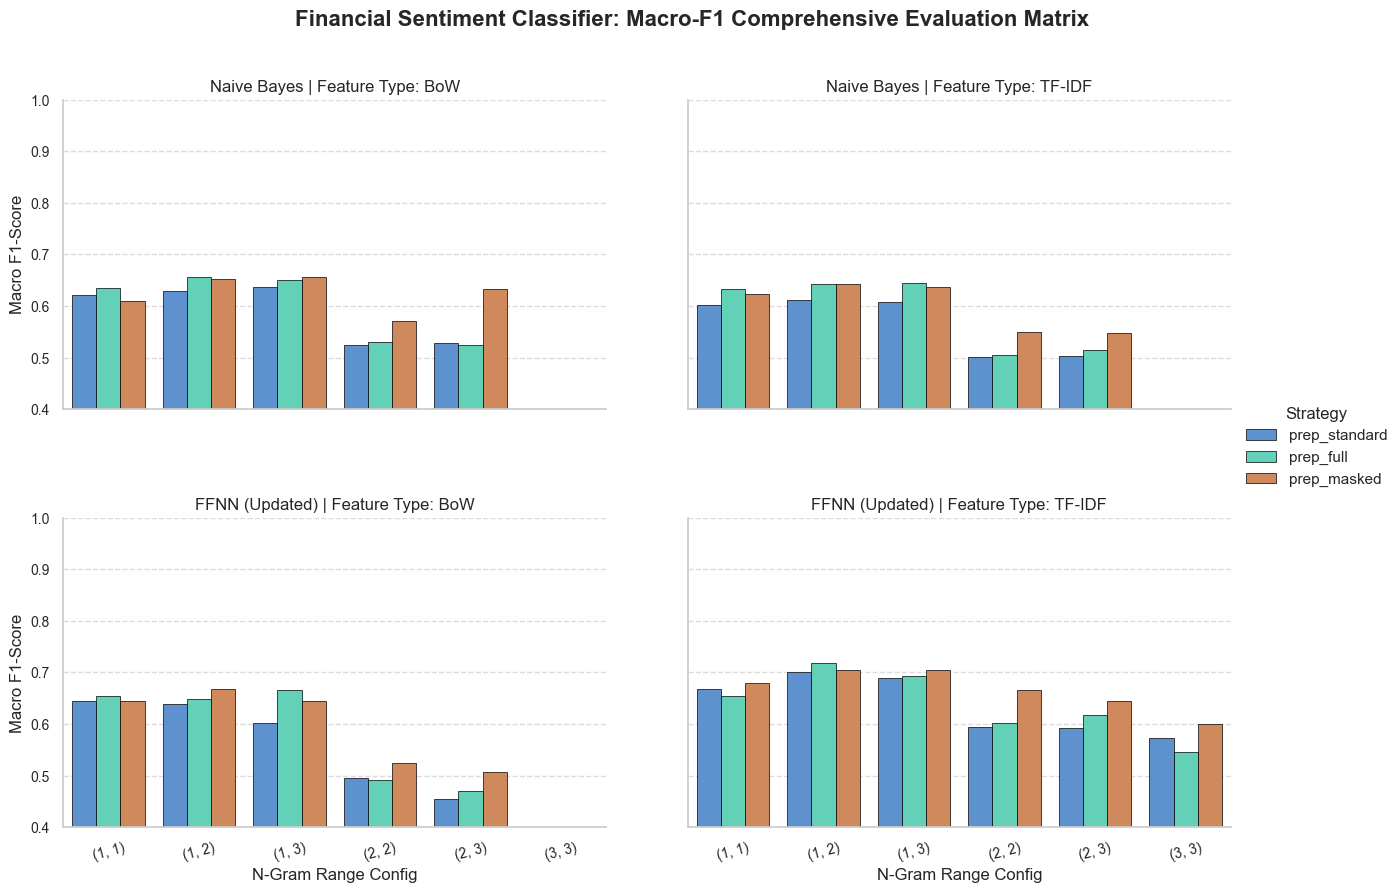

In [11]:
# ==========================================
# 5. SCIENTIFIC VISUALIZATION BLOCK
# ==========================================

# Set high-quality styling for scientific reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# Define a clean, academic, colorblind-friendly palette
strategy_colors = {
    'prep_standard': '#4A90E2',  # Soft Blue
    'prep_full': '#50E3C2',      # Mint Green
    'prep_masked': '#E2844A'     # Muted Orange
}

print("\nGenerating publication-quality performance grid...")

# Initialize the structural grid: Rows = Models, Columns = Vectorizers
g = sns.catplot(
    data=results_df,
    x="N-Gram",
    y="Macro-F1",
    hue="Strategy",
    row="Model",
    col="Vectorizer",
    kind="bar",
    palette=strategy_colors,
    edgecolor="black",
    linewidth=0.5,
    height=4.5,
    aspect=1.4,
    sharex=True,
    sharey=True
)

# Refine layouts, axis titles, and limit parameters cleanly
g.set_axis_labels("N-Gram Range Config", "Macro F1-Score")
g.set_titles(row_template="{row_name}", col_template="Feature Type: {col_name}")

# Fine-tune visual details for each subplot
for ax in g.axes.flat:
    # Set realistic boundaries to highlight differences (adjust min bound based on your data)
    ax.set_ylim(0.40, 1.00)
    ax.yaxis.grid(True, linestyle="--", alpha=0.7)
    ax.xaxis.grid(False) # Drop vertical grids to increase scannability

    # Rotate text labels slightly to prevent overlapping text elements
    for label in ax.get_xticklabels():
        label.set_rotation(15)

# Adjust margins and fix the position of the legend safely
g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.15)
g.fig.suptitle("Financial Sentiment Classifier: Macro-F1 Comprehensive Evaluation Matrix", weight="bold")

# Save a crisp, high-resolution vector image for your report text editor
plt.savefig("sentiment_evaluation_matrix.png", dpi=300, bbox_inches='tight')
print("Graphic saved successfully as 'sentiment_evaluation_matrix.png'!")
plt.show()
